First 5 rows of the dataset:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
Dataset shape:
(1000, 8)

Number of math score values: 1000

IQR METHOD:
Q1: 57.0
Q3: 77.0
IQR: 20.0
Lower limit: 27.0
Upper limit

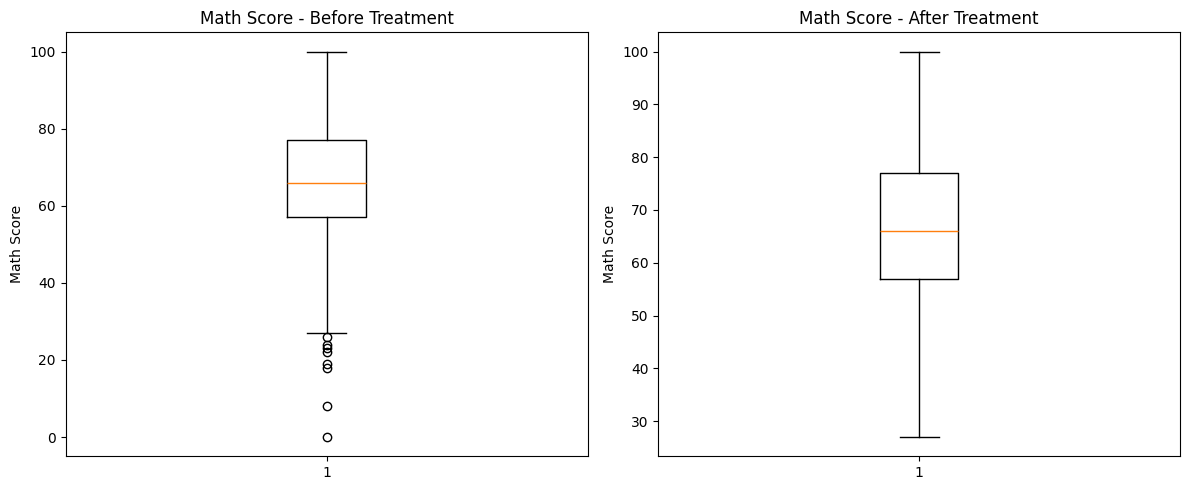

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(r"StudentsPerformance.csv")
print("First 5 rows of the dataset:")
print(df.head())

print("Dataset shape:")
print(df.shape)

data = df["math score"].dropna()
print("\nNumber of math score values:",len(data))

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("\nIQR METHOD:")
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("Lower limit:",lower_limit)
print("Upper limit:",upper_limit)

iqr_outliers = df[(df["math score"] < lower_limit) |
                  (df["math score"] > upper_limit)]
print("\nNumber of IQR outliers:",len(iqr_outliers))

mean = data.mean()
std = data.std()
df["Z_score"] = (df["math score"] - mean) / std

z_outliers = df[abs(df["Z_score"]) > 3]
print("\nZ-score METHOD:")
print("Mean:",mean)
print("Standard deviation:",std)
print("\nNumber of Z-score outliers:",len(z_outliers))

print("\nIQR OUTLIERS")
if len(iqr_outliers) > 0:
    print(iqr_outliers[["math score"]])
else:
    print("No IQR outliers found.")

print("\nZ-SCORE OUTLIERS")
if len(z_outliers) > 0:
    print(z_outliers[["math score","Z_score"]])
else:
    print("No Z-score outliers found.")

df["math_score_treated"] = df["math score"].clip(lower=lower_limit,
                                                 upper=upper_limit)
print("Treated method: Capping using IQR limits")

print("\nBEFORE TREATMENT ")
print(df["math score"].describe())
print("\nAFTER TREATMENT ")
print(df["math_score_treated"].describe())

comparision = df[["math score","math_score_treated"]]

print(comparision.head())

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.boxplot(df["math score"].dropna())
plt.title("Math Score - Before Treatment")
plt.ylabel("Math Score")

plt.subplot(1,2,2)
plt.boxplot(df["math_score_treated"].dropna())
plt.title("Math Score - After Treatment")
plt.ylabel("Math Score")

plt.tight_layout()
plt.show()
